# 01 — Embedding separability (M5 gating check)

**Goal:** project the 1280-dim embedding-only feature matrix to 2D and eyeball whether offender (label=1) and control (label=0) clips form distinguishable regions. Per `PLAN.md` M5, this step is non-negotiable — if classes don't separate visually, **stop and revisit features** before touching a classifier.

Inputs: `data/features/combined.parquet` (94 × 1296). The trailing 16 scalar columns are dropped — see `medea.storage.vector_db.embedding_slice` for the rationale.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT / 'src'))

from medea.features.pipeline import build_dataset
from medea.storage.vector_db import embedding_slice

In [2]:
ds = build_dataset()
X = embedding_slice(ds.X)
labels = ds.labels
channel_ids = ds.channel_ids
print(f'X={X.shape}  pos={int(labels.sum())} neg={int((labels==0).sum())} channels={len(set(channel_ids.tolist()))}')
print(f'block sizes: {ds.block_sizes}')

X=(94, 1280)  pos=44 neg=50 channels=10
block sizes: {'visual': 512, 'transcript': 384, 'title_desc': 384, 'scalars': 18}


In [3]:
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='cosine', random_state=42, n_jobs=1)
embedding_2d = reducer.fit_transform(X)
embedding_2d.shape

(94, 2)

wrote C:\Users\mathi\work\medea\data\features\umap.png


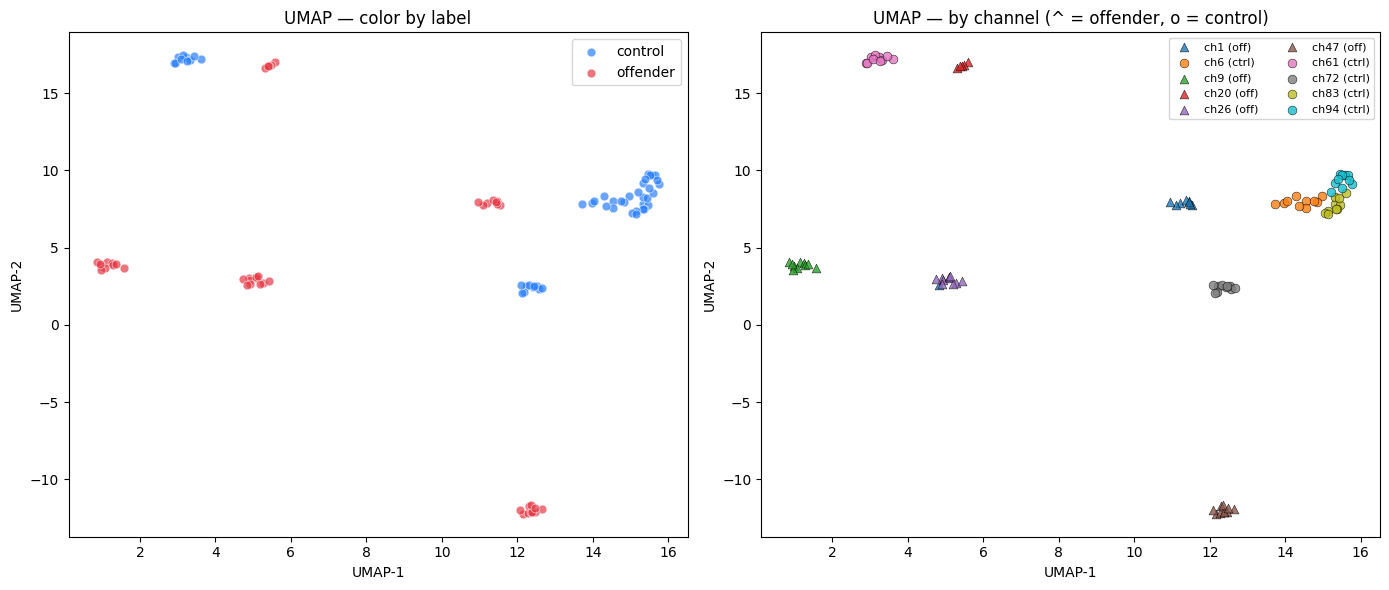

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for lbl, color, name in [(0, '#2a7fff', 'control'), (1, '#e63946', 'offender')]:
    m = labels == lbl
    ax.scatter(embedding_2d[m, 0], embedding_2d[m, 1], c=color, label=name, s=40, alpha=0.7, edgecolors='white', linewidths=0.5)
ax.set_title('UMAP — color by label')
ax.legend()
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

ax = axes[1]
channels = sorted(set(channel_ids.tolist()))
cmap = plt.get_cmap('tab10')
for i, cid in enumerate(channels):
    m = channel_ids == cid
    label_for_ch = int(labels[m][0])
    marker = 'o' if label_for_ch == 0 else '^'
    ax.scatter(embedding_2d[m, 0], embedding_2d[m, 1], c=[cmap(i % 10)], label=f'ch{cid} ({"off" if label_for_ch else "ctrl"})', s=40, marker=marker, alpha=0.8, edgecolors='black', linewidths=0.4)
ax.set_title('UMAP — by channel (^ = offender, o = control)')
ax.legend(fontsize=8, loc='best', ncol=2)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

out = PROJECT / 'data' / 'features' / 'umap.png'
fig.tight_layout()
fig.savefig(out, dpi=120, bbox_inches='tight')
print(f'wrote {out}')
plt.show()

## kNN spot check (channel-level leave-one-out)

Honest measure: for each video, exclude *all videos from the same channel* before querying its 5 nearest neighbors. This is the closest thing to the channel-level holdout that M6 will use.

If accuracy is well below the plan's M6 bar of 0.7 precision, treat that as a feature-quality problem rather than something a classifier will fix.

In [5]:
from medea.storage.vector_db import get_collection, knn_query

col = get_collection()
print('collection size:', col.count())

K = 5
preds = np.zeros(len(ds.video_ids), dtype=int)
scores = np.zeros(len(ds.video_ids), dtype=float)
for i, vid in enumerate(ds.video_ids):
    same_ch = [ds.video_ids[j] for j in range(len(ds.video_ids)) if channel_ids[j] == channel_ids[i]]
    r = knn_query(col, X[i], k=K, exclude_ids=same_ch)
    scores[i] = r.score
    preds[i] = 1 if r.score >= 0.5 else 0

tp = ((preds == 1) & (labels == 1)).sum()
fp = ((preds == 1) & (labels == 0)).sum()
fn = ((preds == 0) & (labels == 1)).sum()
tn = ((preds == 0) & (labels == 0)).sum()
acc = (preds == labels).mean()
prec = tp / max(1, tp + fp)
rec  = tp / max(1, tp + fn)
f1   = 2 * prec * rec / max(1e-9, prec + rec)
print(f'channel-level LOO  k={K}  acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}')
print(f'                  tp={tp} fp={fp} fn={fn} tn={tn}')

collection size: 94


channel-level LOO  k=5  acc=0.809  prec=0.861  rec=0.705  f1=0.775
                  tp=31 fp=5 fn=13 tn=45


In [6]:
# Per-channel breakdown — find which channels the kNN baseline struggles with
rows = []
for cid in sorted(set(channel_ids.tolist())):
    m = channel_ids == cid
    rows.append({
        'channel_id': cid,
        'label': int(labels[m][0]),
        'n': int(m.sum()),
        'acc': float((preds[m] == labels[m]).mean()),
        'mean_score': float(scores[m].mean()),
    })
pd.DataFrame(rows).sort_values('acc')

,channel_id,label,n,acc,mean_score
3,20,1,5,0.000000,0.232620
0,1,1,9,0.111111,0.240464
7,72,0,10,0.600000,0.461761
6,61,0,10,0.900000,0.350022
2,9,1,10,1.000000,0.978972
1,6,0,10,1.000000,0.118569
5,47,1,10,1.000000,1.000000
4,26,1,10,1.000000,1.000000
8,83,0,10,1.000000,0.019736
9,94,0,10,1.000000,0.000000
